![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [109]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [110]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-12 10:15:50.260 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


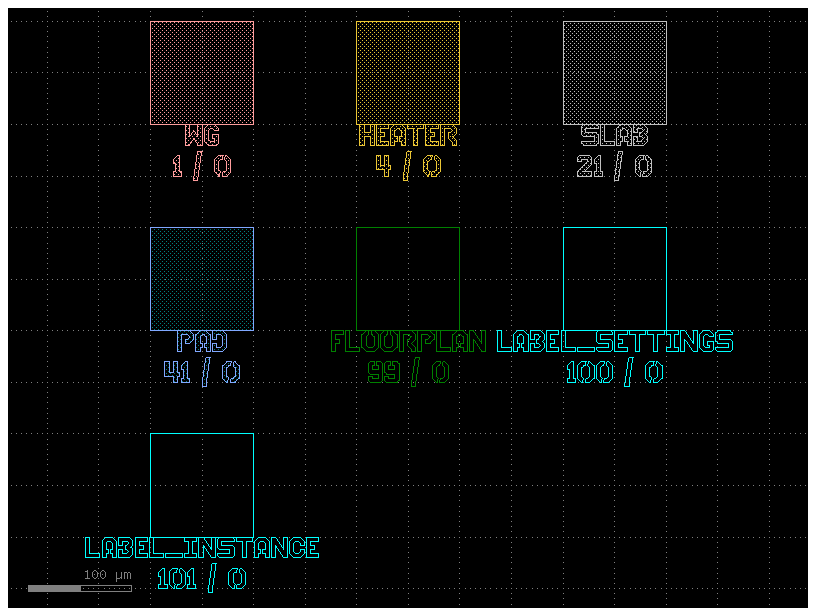

In [111]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-12 10:15:50.406 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


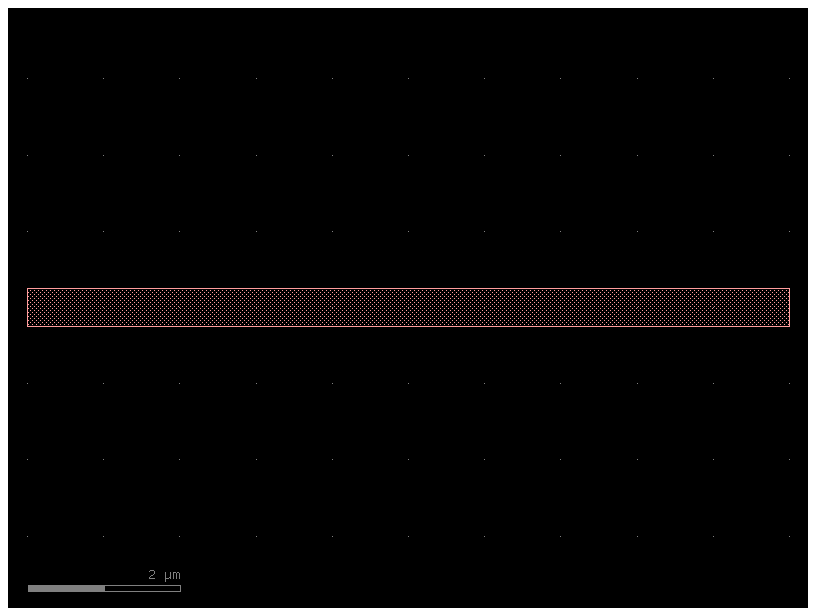

In [112]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-12 10:15:50.563 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 10:15:50.587 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


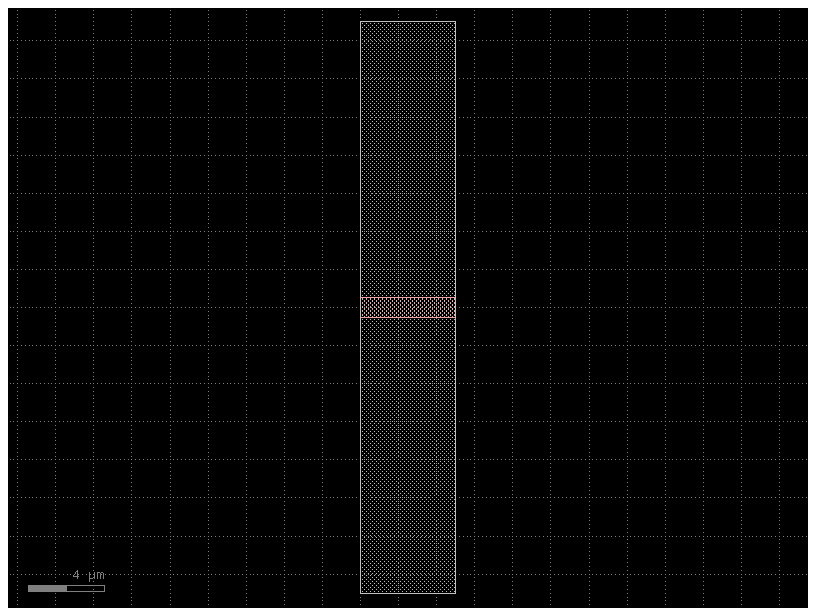

In [113]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [114]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-12 10:15:50.710 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-12 10:15:50.832 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


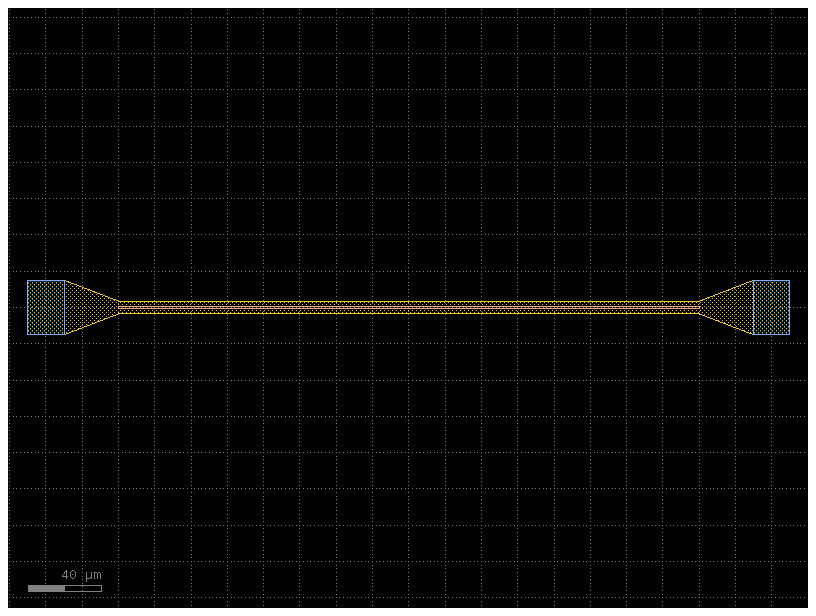

In [115]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

2026-06-12 10:15:50.989 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center          ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 0.5   │ 180.0       │ WG (1/0) │ (-10.0, -4.45)  │ optical   │
│ o2   │ 0.5   │ 180.0       │ WG (1/0) │ (-10.0, 5.55)   │ optical   │
│ o3   │ 0.5   │ 0.0         │ WG (1/0) │ (57.014, 5.55)  │ optical   │
│ o4   │ 0.5   │ 0.0         │ WG (1/0) │ (57.014, -4.45) │ optical   │
└──────┴───────┴─────────────┴──────────┴─────────────────┴───────────┘

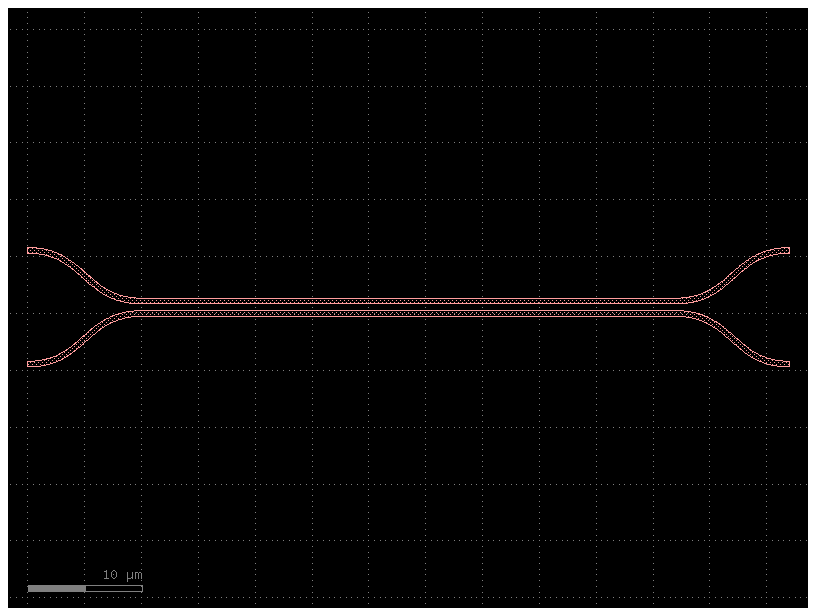

In [116]:
# Directional Coupler 2x2 - Lab2 design

xs_dc = gf.cross_section.strip(width=0.5, layer="WG")

L_pi_lab2 = 94.027       # um
gap_lab2 = 0.6           # um
L_coupler_lab2 = L_pi_lab2 / 2

dc_lab2 = gf.components.coupler(
    gap=gap_lab2,
    length=L_coupler_lab2,
    dx=10.0,
    dy=10.0,
    cross_section=xs_dc,
    allow_min_radius_violation=True,
)

dc_lab2.plot()
dc_lab2.show()
dc_lab2.pprint_ports()

2026-06-12 10:15:51.111 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center           ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, -1.165)  │ optical   │
│ o2   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, 1.165)   │ optical   │
│ o3   │ 1.7   │ 0.0         │ WG (1/0) │ (53.918, 1.165)  │ optical   │
│ o4   │ 1.7   │ 0.0         │ WG (1/0) │ (53.918, -1.165) │ optical   │
└──────┴───────┴─────────────┴──────────┴──────────────────┴───────────┘

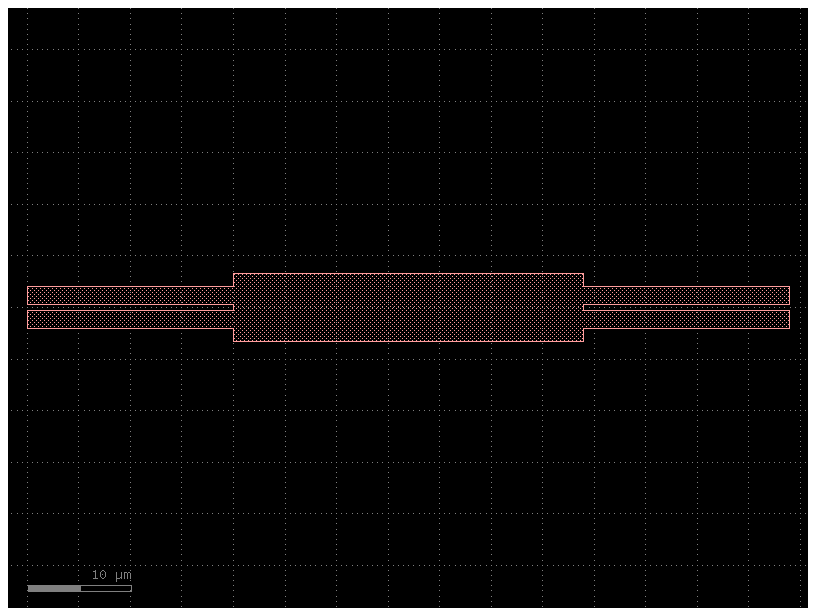

In [117]:
# MMI 2x2 - Lab2 design

W_MMI_lab2 = 6.6
L_pi_MMI_lab2 = 69.035986
dL_MMI_lab2 = -0.60
dy_lab2 = 0.065

L_MMI_lab2 = 0.5 * L_pi_MMI_lab2 + dL_MMI_lab2
io_position = W_MMI_lab2 / 6 + dy_lab2

io_width = 1.0 + 0.7
gap_mmi = 2 * io_position - io_width

mmi_2x2_lab2 = cells.mmi2x2(
    width=io_width,
    width_taper=io_width,
    length_mmi=L_MMI_lab2,
    width_mmi=W_MMI_lab2,
    gap_mmi=gap_mmi,
    cross_section="strip",
)

mmi_2x2_lab2.plot()
mmi_2x2_lab2.show()
mmi_2x2_lab2.pprint_ports()

2026-06-12 10:15:51.219 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center            ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, -1.165)   │ optical   │
│ o2   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, 1.165)    │ optical   │
│ o4   │ 1.7   │ 0.0         │ WG (1/0) │ (527.936, -1.165) │ optical   │
│ o3   │ 1.7   │ 0.0         │ WG (1/0) │ (527.936, 1.165)  │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────────┴───────────┘

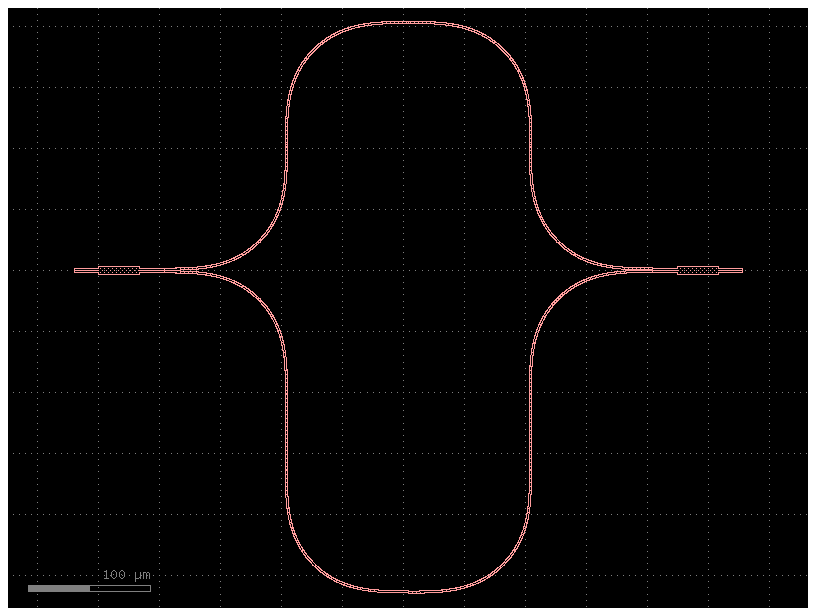

In [118]:
# LO1b - Unbalanced MZI from Lab3
# Lab3 design: FSR target = 10 nm -> Delta L = 120.125 um

delta_L_lab3 = 120.125  # um

xs_mzi = gf.cross_section.strip(
    width=1.7,
    layer="WG",
)

mzi_lab3 = cells.mzi(
    delta_length=delta_L_lab3,
    splitter=mmi_2x2_lab2,
    combiner=mmi_2x2_lab2,
    cross_section=xs_mzi,
)

mzi_lab3.plot()
mzi_lab3.show()
mzi_lab3.pprint_ports()

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center        ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o2   │ 0.5   │ 0.0         │ WG (1/0) │ (100.0, 0.0)  │ optical   │
│ o1   │ 0.5   │ 180.0       │ WG (1/0) │ (-110.0, 0.0) │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────┴───────────┘

2026-06-12 10:15:51.364 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
L_ring from Lab3 = 80.08 um
Equivalent radius used in layout = 12.75 um
Target coupling coefficient K = 0.5
Gap used in layout = 0.25 um
Coupling section length = 10.00 um


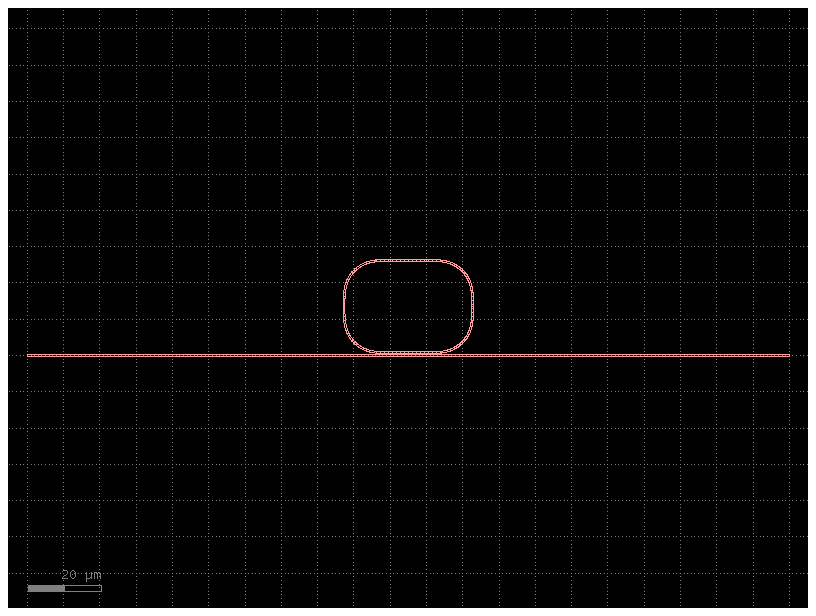

In [119]:
# Ring resonator - Lab3 design

import numpy as np

L_RING_LAB3 = 80.08      # um, ring length obtained in Lab3
K_RING_LAB3 = 0.5        # target coupling coefficient from Lab3

R_RING = L_RING_LAB3 / (2 * np.pi)   # equivalent ring radius
GAP_RING = 0.25                      # um
L_COUPLING = 10.0                    # um, straight coupling section

xs_ring = gf.cross_section.strip(
    width=0.5,
    layer="WG",
    radius=R_RING,
    radius_min=5,
)

ring_lab3 = gf.components.ring_single(
    radius=R_RING,
    gap=GAP_RING,
    length_x=L_COUPLING,
    length_y=0.0,
    cross_section=xs_ring,
)

ring_lab3.plot()
ring_lab3.show()
ring_lab3.pprint_ports()

print(f"L_ring from Lab3 = {L_RING_LAB3:.2f} um")
print(f"Equivalent radius used in layout = {R_RING:.2f} um")
print(f"Target coupling coefficient K = {K_RING_LAB3}")
print(f"Gap used in layout = {GAP_RING:.2f} um")
print(f"Coupling section length = {L_COUPLING:.2f} um")

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-12 10:15:51.466 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


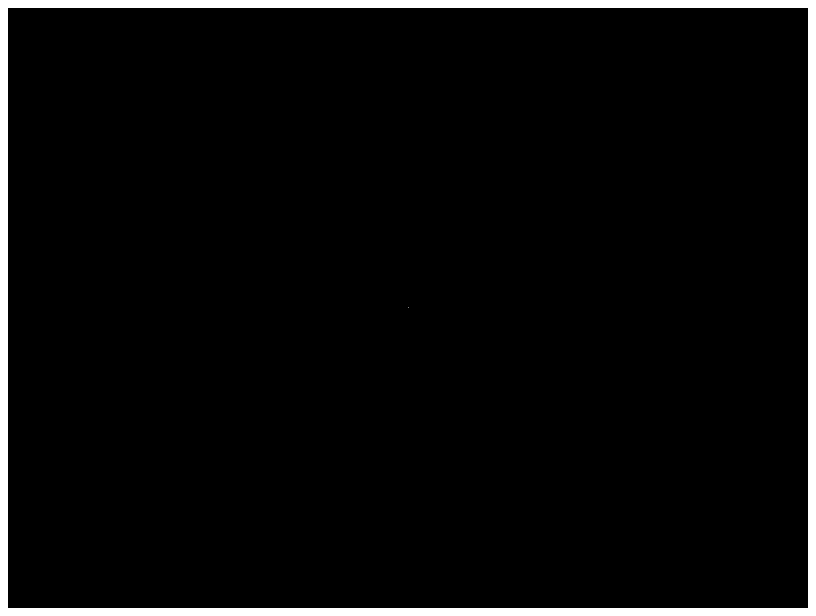

In [120]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-12 10:15:51.545 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


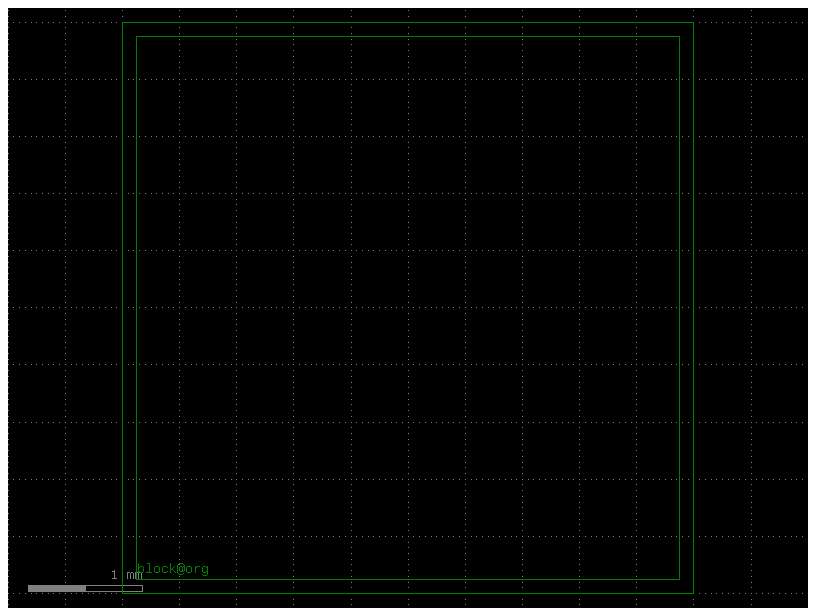

In [121]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-12 10:15:51.700 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


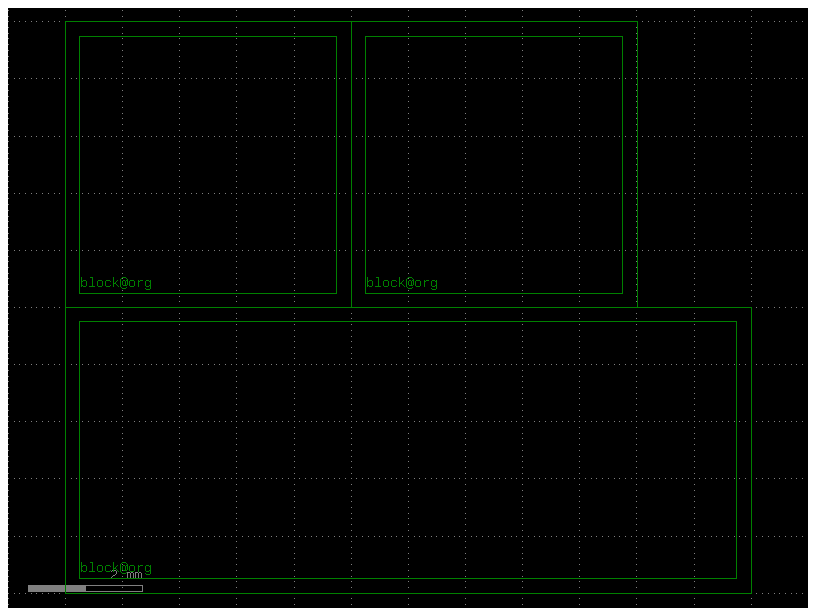

In [122]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


2026-06-12 10:15:51.860 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


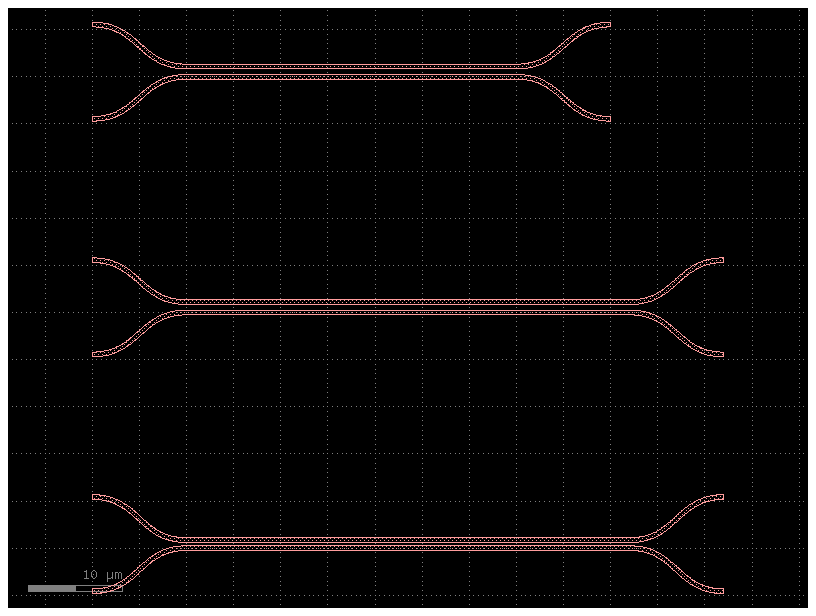

In [123]:
# LO2a - Directional Coupler 2x2 as reusable and parametric cell

gf.clear_cache()

@gf.cell
def dc_50_50_lab2(
    L_pi=94.027,
    gap=0.6,
    dx=10.0,
    dy=10.0,
):
    xs_dc = gf.cross_section.strip(width=0.5, layer="WG")
    
    return gf.components.coupler(
        gap=gap,
        length=L_pi / 2,
        dx=dx,
        dy=dy,
        cross_section=xs_dc,
        allow_min_radius_violation=True,
    )

# Parent component where we instantiate the same cell with different parameters
top_dc = gf.Component("parametric_dc_examples")

dc_lab2 = top_dc << dc_50_50_lab2(L_pi=94.027, gap=0.6)
dc_short = top_dc << dc_50_50_lab2(L_pi=70.0, gap=0.6)
dc_small_gap = top_dc << dc_50_50_lab2(L_pi=94.027, gap=0.35)

dc_short.movey(25)
dc_small_gap.movey(-25)

top_dc.plot()
top_dc.show()

2026-06-12 10:15:52.012 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


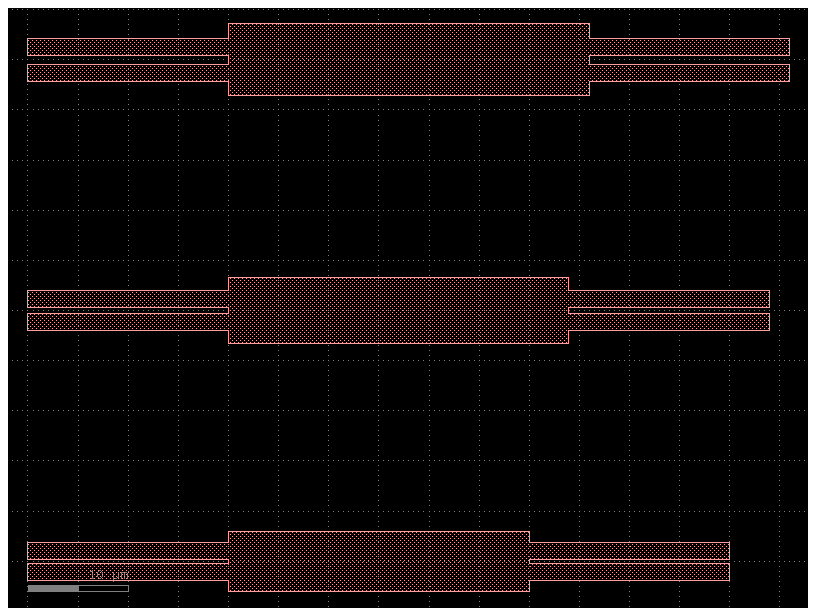

In [124]:
# LO2a - MMI 2x2 as reusable and parametric cell

gf.clear_cache()

@gf.cell
def mmi2x2_lab2_cell(
    W_MMI=6.6,
    L_MMI=33.918,
    dy=0.065,
    access_width=1.7,
):
    io_position = W_MMI / 6 + dy
    gap_mmi = 2 * io_position - access_width

    return cells.mmi2x2(
        width=access_width,
        width_taper=access_width,
        length_mmi=L_MMI,
        width_mmi=W_MMI,
        gap_mmi=gap_mmi,
        cross_section="strip",
    )

# Parent component: same cell reused with different parameters
top_mmi = gf.Component("parametric_mmi2x2_examples")

mmi_lab2 = top_mmi << mmi2x2_lab2_cell(
    W_MMI=6.6,
    L_MMI=33.918,
    dy=0.065,
)

mmi_wider = top_mmi << mmi2x2_lab2_cell(
    W_MMI=7.2,
    L_MMI=36.0,
    dy=0.08,
)

mmi_shorter = top_mmi << mmi2x2_lab2_cell(
    W_MMI=6.0,
    L_MMI=30.0,
    dy=0.05,
)

mmi_wider.movey(25)
mmi_shorter.movey(-25)

top_mmi.plot()
top_mmi.show()

2026-06-12 10:15:52.135 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center            ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, -1.165)   │ optical   │
│ o2   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, 1.165)    │ optical   │
│ o4   │ 1.7   │ 0.0         │ WG (1/0) │ (527.936, -1.165) │ optical   │
│ o3   │ 1.7   │ 0.0         │ WG (1/0) │ (527.936, 1.165)  │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────────┴───────────┘

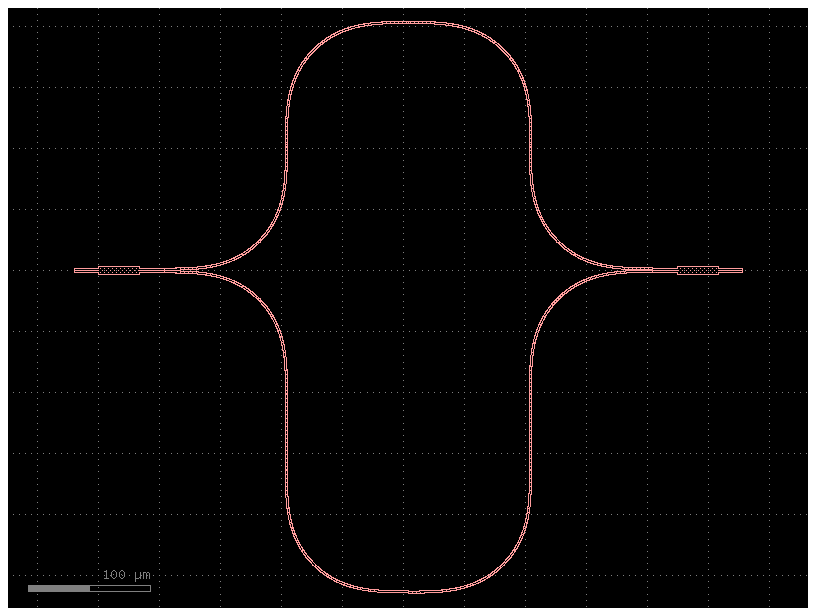

In [125]:
# LO2a - MZI from Lab3 as reusable cell

gf.clear_cache()

@gf.cell
def mzi_lab3_cell(
    delta_L=120.125,
):
    xs_mzi = gf.cross_section.strip(
        width=1.7,
        layer="WG",
    )

    splitter = mmi2x2_lab2_cell()
    combiner = mmi2x2_lab2_cell()

    return cells.mzi(
        delta_length=delta_L,
        splitter=splitter,
        combiner=combiner,
        cross_section=xs_mzi,
    )

mzi_lab3_reusable = mzi_lab3_cell(delta_L=120.125)

mzi_lab3_reusable.plot()
mzi_lab3_reusable.show()
mzi_lab3_reusable.pprint_ports()

2026-06-12 10:15:52.284 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


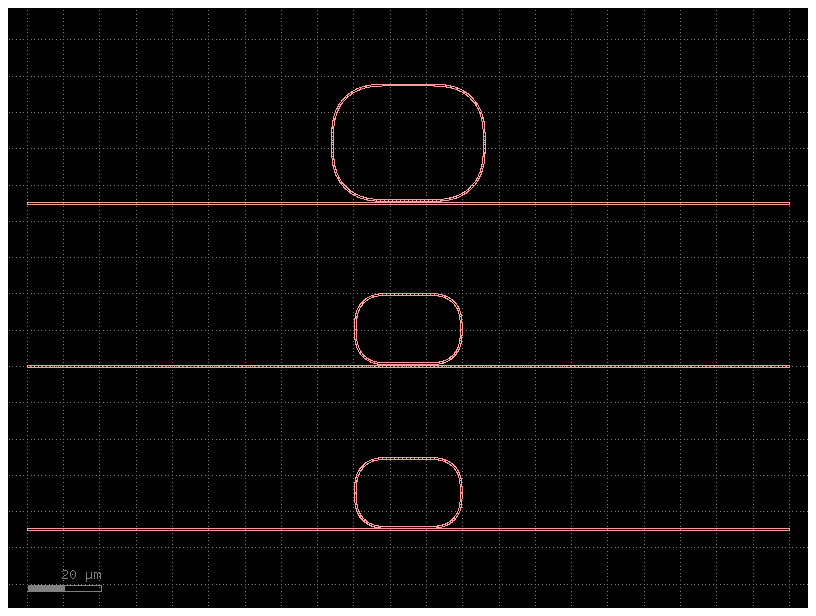

In [126]:
# LO2a - Ring resonator from Lab3 as reusable and parametric cell

gf.clear_cache()

@gf.cell
def ring_lab3_cell(
    L_ring=80.08,
    gap=0.25,
    coupling_length=10.0,
):
    # Racetrack approximation:
    # L_ring ≈ 2*pi*R + 2*coupling_length
    R_ring = (L_ring - 2 * coupling_length) / (2 * np.pi)

    xs_ring = gf.cross_section.strip(
        width=0.5,
        layer="WG",
        radius=R_ring,
        radius_min=5,
    )

    return gf.components.ring_single(
        radius=R_ring,
        gap=gap,
        length_x=coupling_length,
        length_y=0.0,
        cross_section=xs_ring,
    )

# Parent component: same ring cell reused with different parameters
top_ring = gf.Component("parametric_ring_examples")

ring_lab3 = top_ring << ring_lab3_cell(
    L_ring=80.08,
    gap=0.25,
    coupling_length=10.0,
)

ring_larger = top_ring << ring_lab3_cell(
    L_ring=120.0,
    gap=0.25,
    coupling_length=10.0,
)

ring_smaller_gap = top_ring << ring_lab3_cell(
    L_ring=80.08,
    gap=0.15,
    coupling_length=10.0,
)

ring_larger.movey(45)
ring_smaller_gap.movey(-45)

top_ring.plot()
top_ring.show()

## 3. Complete Layout

2026-06-12 10:15:52.403 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


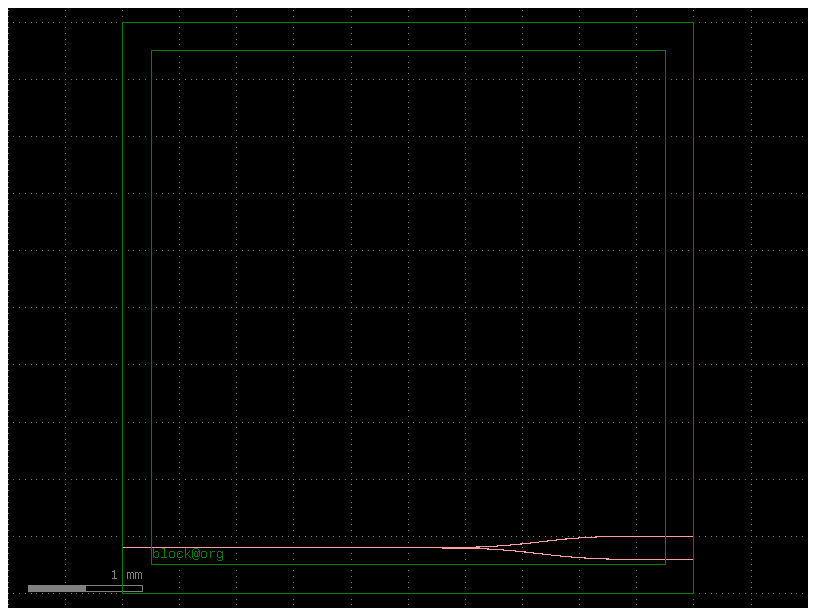

In [127]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

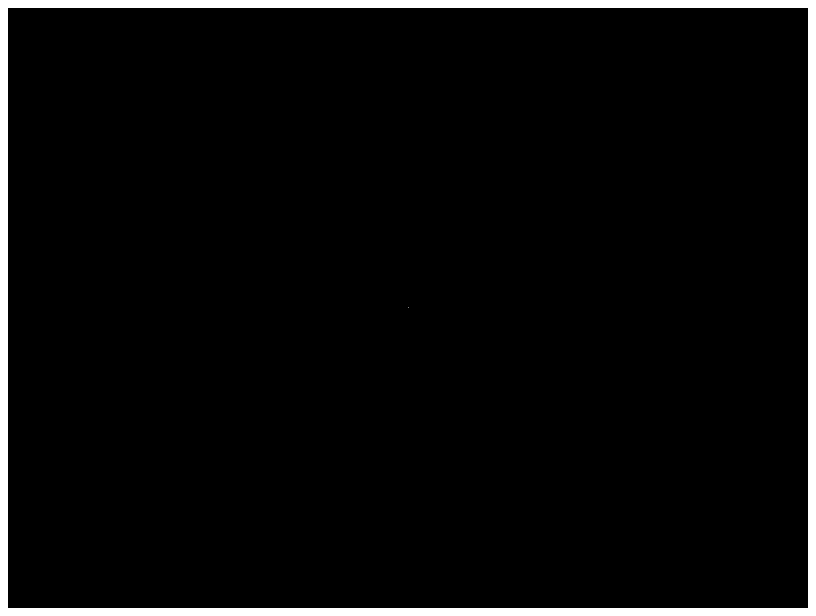

In [128]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()
...
c.plot()

2026-06-12 10:15:52.589 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


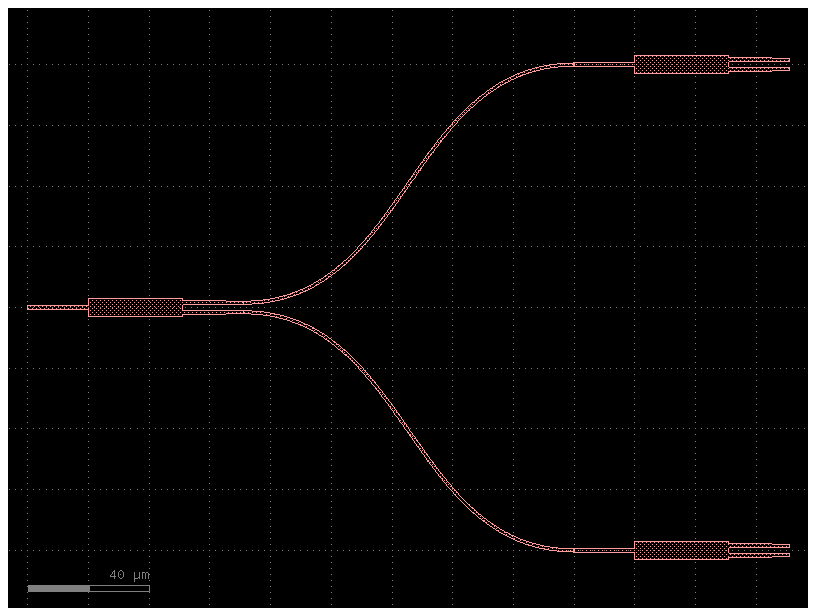

In [129]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()

mmi1 = c.add_ref(c_mmi)
mmi2 = c.add_ref(c_mmi)
mmi3 = c.add_ref(c_mmi)

mmi2.dmovex(180).dmovey(80)
mmi3.dmovex(180).dmovey(-80)

gf.routing.route_single_sbend(
    component=c,
    port1=mmi1["o2"],
    port2=mmi2["o1"],
    cross_section="strip",
)

gf.routing.route_single_sbend(
    component=c,
    port1=mmi1["o3"],
    port2=mmi3["o1"],
    cross_section="strip",
)

c.plot()
c.show()

In [130]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

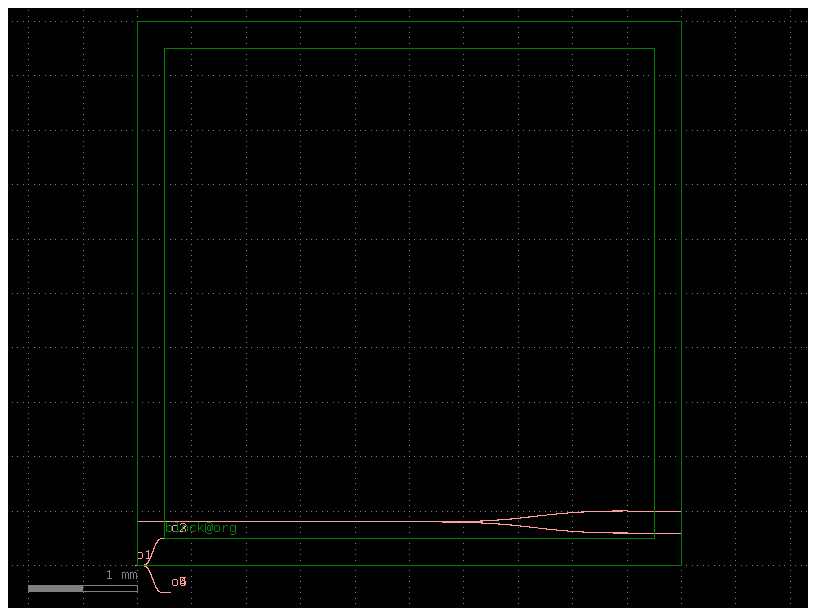

In [131]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-12 10:15:52.816 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


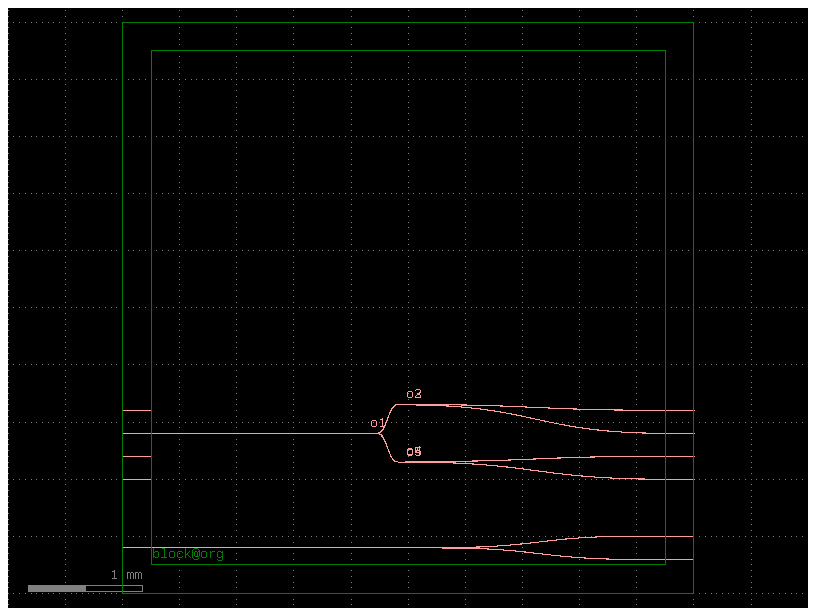

In [132]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center            ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, -1.165)   │ optical   │
│ o2   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, 1.165)    │ optical   │
│ o4   │ 1.7   │ 0.0         │ WG (1/0) │ (527.936, -1.165) │ optical   │
│ o3   │ 1.7   │ 0.0         │ WG (1/0) │ (527.936, 1.165)  │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────────┴───────────┘

2026-06-12 10:15:52.936 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


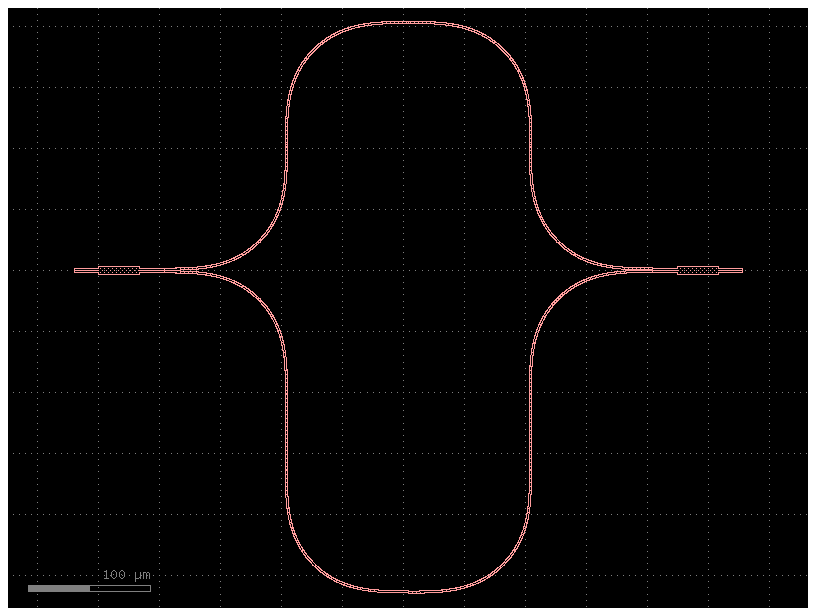

In [133]:
# LO4 - Part a.1
# Cell for an unbalanced MZI using 2x2 50:50 MMIs

gf.clear_cache()

@gf.cell
def mmi2x2_50_50_lab2():
    W_MMI = 6.6
    L_MMI = 33.918
    dy = 0.065
    access_width = 1.7

    io_position = W_MMI / 6 + dy
    gap_mmi = 2 * io_position - access_width

    return cells.mmi2x2(
        width=access_width,
        width_taper=access_width,
        length_mmi=L_MMI,
        width_mmi=W_MMI,
        gap_mmi=gap_mmi,
        cross_section="strip",
    )


@gf.cell
def unbalanced_mzi_lab3(delta_L=120.125):
    xs_mzi = gf.cross_section.strip(
        width=1.7,
        layer="WG",
    )

    splitter = mmi2x2_50_50_lab2()
    combiner = mmi2x2_50_50_lab2()

    return cells.mzi(
        delta_length=delta_L,
        splitter=splitter,
        combiner=combiner,
        cross_section=xs_mzi,
    )


mzi_exercise = unbalanced_mzi_lab3(delta_L=120.125)

mzi_exercise.plot()
mzi_exercise.show()
mzi_exercise.pprint_ports()

2026-06-12 10:15:53.057 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center            ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, -1.165)   │ optical   │
│ o2   │ 1.7   │ 180.0       │ WG (1/0) │ (-20.0, 1.165)    │ optical   │
│ o3   │ 1.7   │ 0.0         │ WG (1/0) │ (527.936, 1.165)  │ optical   │
│ o4   │ 1.7   │ 0.0         │ WG (1/0) │ (527.936, -1.165) │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────────┴───────────┘

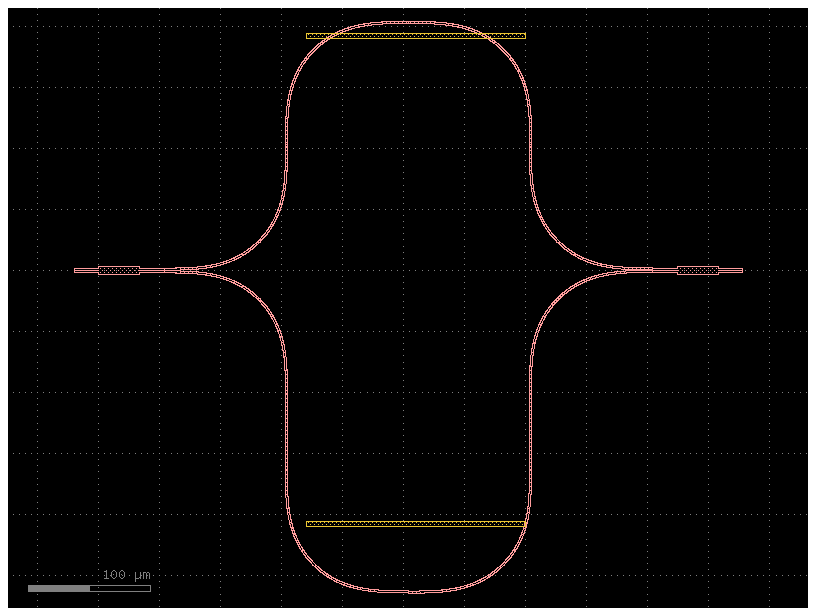

In [134]:
# LO4 - Part a.2
# Unbalanced MZI with thermal tuners on both arms

@gf.cell
def unbalanced_mzi_with_heaters_lab3(
    delta_L=120.125,
    heater_length=180.0,
    heater_width=4.0,
):
    c = gf.Component()

    # Base MZI from previous exercise
    mzi = c << unbalanced_mzi_lab3(delta_L=delta_L)

    # Approximate heater rectangles placed over the two MZI arms
    heater_top = c << gf.components.rectangle(
        size=(heater_length, heater_width),
        layer="HEATER",
    )

    heater_bottom = c << gf.components.rectangle(
        size=(heater_length, heater_width),
        layer="HEATER",
    )

    # Placement over the upper and lower arms
    heater_top.dmovex(170).dmovey(190)
    heater_bottom.dmovex(170).dmovey(-210)

    # Keep the optical ports of the MZI accessible
    c.add_port("o1", port=mzi["o1"])
    c.add_port("o2", port=mzi["o2"])
    c.add_port("o3", port=mzi["o3"])
    c.add_port("o4", port=mzi["o4"])

    return c


mzi_heaters_exercise = unbalanced_mzi_with_heaters_lab3(
    delta_L=120.125,
    heater_length=180.0,
    heater_width=4.0,
)

mzi_heaters_exercise.plot()
mzi_heaters_exercise.show()
mzi_heaters_exercise.pprint_ports()

2026-06-12 10:15:53.223 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center        ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o2   │ 0.5   │ 0.0         │ WG (1/0) │ (100.0, 0.0)  │ optical   │
│ o1   │ 0.5   │ 180.0       │ WG (1/0) │ (-110.0, 0.0) │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────┴───────────┘

Base perimeter from Lab3 = 80.08 um
Extra length = 240.0 um
Total perimeter = 320.08 um


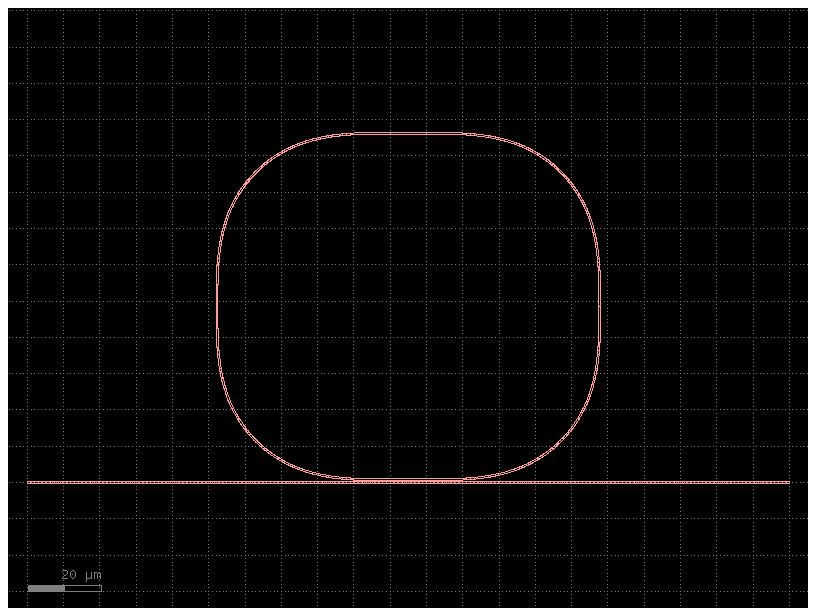

In [135]:
# LO4 - Part a.3
# All-pass ring resonator with extra length parameter

import numpy as np

@gf.cell
def all_pass_ring_lab3(
    extra_length=0.0,
    L_ring_base=80.08,
    gap=0.25,
    coupling_length=10.0,
):
    # Total ring perimeter:
    # base value from Lab3 + extra length
    L_ring_total = L_ring_base + extra_length

    # Racetrack approximation:
    # L_ring_total ≈ 2*pi*R + 2*coupling_length
    R_ring = (L_ring_total - 2 * coupling_length) / (2 * np.pi)

    xs_ring = gf.cross_section.strip(
        width=0.5,
        layer="WG",
        radius=R_ring,
        radius_min=5,
    )

    return gf.components.ring_single(
        radius=R_ring,
        gap=gap,
        length_x=coupling_length,
        length_y=0.0,
        cross_section=xs_ring,
    )


ring_exercise = all_pass_ring_lab3(
    L_ring_base=80.08,     # Lab3 value
    extra_length=240.0,    # added to obtain a larger perimeter
    gap=0.25,
    coupling_length=10.0,
)

ring_exercise.plot()
ring_exercise.show()
ring_exercise.pprint_ports()

print("Base perimeter from Lab3 = 80.08 um")
print("Extra length = 240.0 um")
print("Total perimeter = 320.08 um")

2026-06-12 10:15:53.403 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center         ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 0.5   │ 180.0       │ WG (1/0) │ (-60.759, 0.0) │ optical   │
│ o2   │ 0.5   │ 0.0         │ WG (1/0) │ (50.759, 0.0)  │ optical   │
└──────┴───────┴─────────────┴──────────┴────────────────┴───────────┘

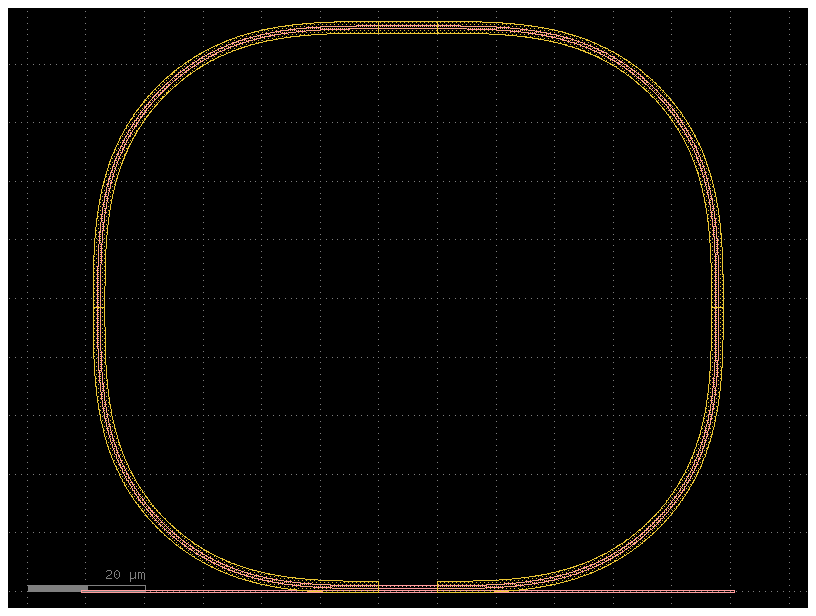

In [136]:
# LO4 - Part a.4
# All-pass ring resonator with heater along the perimeter

@gf.cell
def all_pass_ring_with_heater_lab3(
    extra_length=240.0,
    L_ring_base=80.08,
    gap=0.25,
    coupling_length=10.0,
    heater_width=2.0,
):
    c = gf.Component()

    L_ring_total = L_ring_base + extra_length
    R_ring = (L_ring_total - 2 * coupling_length) / (2 * np.pi)

    xs_wg = gf.cross_section.strip(
        width=0.5,
        layer="WG",
        radius=R_ring,
        radius_min=5,
    )

    xs_ring_heater = gf.cross_section.cross_section(
        width=0.5,
        layer="WG",
        radius=R_ring,
        radius_min=5,
        sections=(
            gf.cross_section.Section(
                name="heater",
                width=heater_width,
                layer="HEATER",
            ),
        ),
    )

    coupler = c << gf.components.coupler_ring(
        gap=gap,
        radius=R_ring,
        length_x=coupling_length,
        cross_section=xs_wg,
        cross_section_bend=xs_ring_heater,
    )

    left_straight = c << gf.components.straight(
        length=0.01,
        cross_section=xs_ring_heater,
    )

    right_straight = c << gf.components.straight(
        length=0.01,
        cross_section=xs_ring_heater,
    )

    left_bend = c << gf.components.bend_euler(
        radius=R_ring,
        cross_section=xs_ring_heater,
    )

    right_bend = c << gf.components.bend_euler(
        radius=R_ring,
        cross_section=xs_ring_heater,
    )

    top_straight = c << gf.components.straight(
        length=coupling_length,
        cross_section=xs_ring_heater,
    )

    left_straight.connect("o1", coupler["o2"])
    left_bend.connect("o2", left_straight["o2"])
    top_straight.connect("o2", left_bend["o1"])
    right_bend.connect("o2", top_straight["o1"])
    right_straight.connect("o1", right_bend["o1"])
    right_straight.connect("o2", coupler["o3"])

    c.add_port("o1", port=coupler["o1"])
    c.add_port("o2", port=coupler["o4"])

    return c


ring_heater_exercise = all_pass_ring_with_heater_lab3(
    L_ring_base=80.08,
    extra_length=240.0,
    gap=0.25,
    coupling_length=10.0,
    heater_width=2.0,
)

ring_heater_exercise.plot()
ring_heater_exercise.show()
ring_heater_exercise.pprint_ports()

2026-06-12 10:15:53.560 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center         ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.0   │ 0.0         │ WG (1/0) │ (718.0, -18.0) │ optical   │
│ o2   │ 1.0   │ 0.0         │ WG (1/0) │ (721.0, -21.0) │ optical   │
└──────┴───────┴─────────────┴──────────┴────────────────┴───────────┘

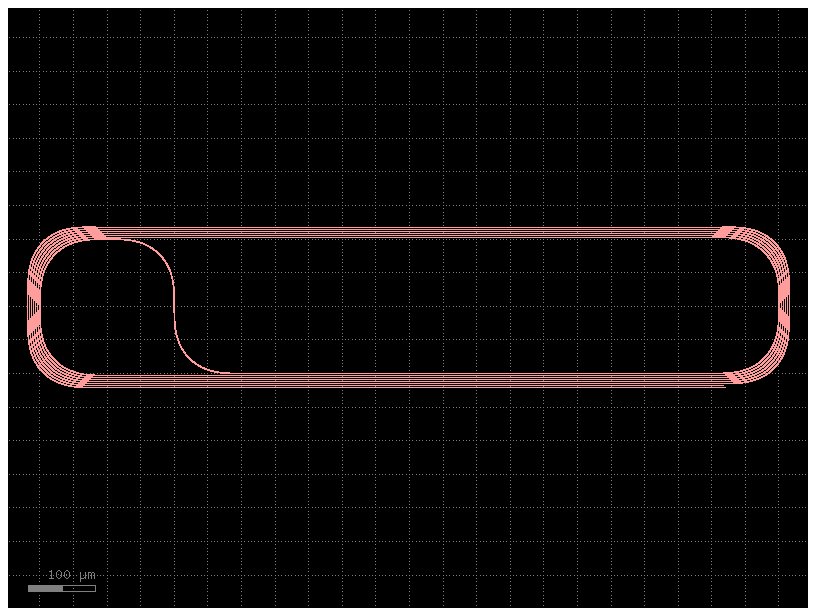

In [137]:
# LO4 - Part a.5
# Spiral component with length as parameter

gf.clear_cache()

@gf.cell
def spiral_lab4(
    length=700.0,
    spacing=3.0,
    n_loops=6,
):
    return cells.spiral(
        length=length,
        spacing=spacing,
        n_loops=n_loops,
        cross_section="strip",
    )


spiral_exercise = spiral_lab4(
    length=700.0,
    spacing=3.0,
    n_loops=6,
)

spiral_exercise.plot()
spiral_exercise.show()
spiral_exercise.pprint_ports()

2026-06-12 10:15:53.670 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


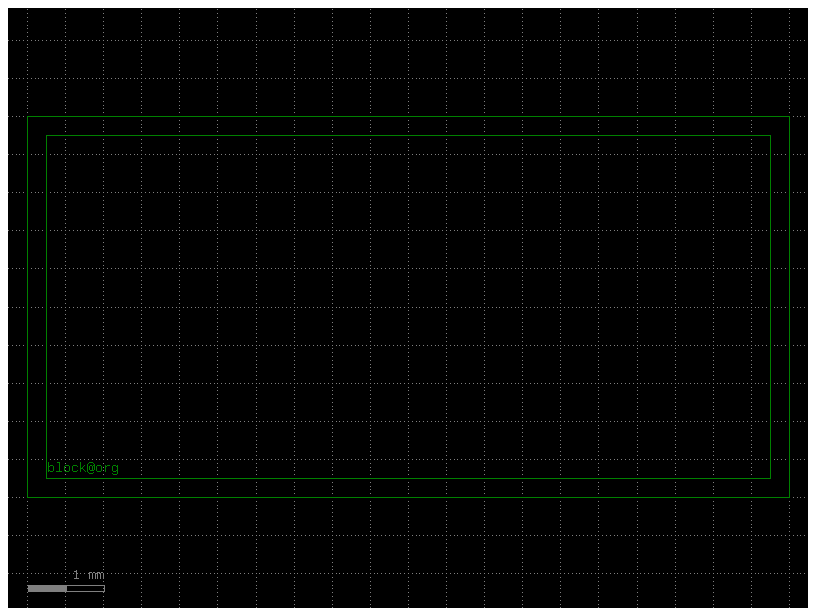

In [138]:
# LO4 - Part b.1
# Die: width = 5 mm, length = 10 mm

DIE_WIDTH = 5000.0    # um, eje y
DIE_LENGTH = 10000.0  # um, eje x
BORDER = 250.0        # um

die_b1 = die(
    dieL=DIE_WIDTH,
    dieW=DIE_LENGTH,
    border=BORDER,
    layer_box="FLOORPLAN",
)

die_b1.plot()
die_b1.show()

Number of I/Os per side: 19
2026-06-12 10:15:53.778 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


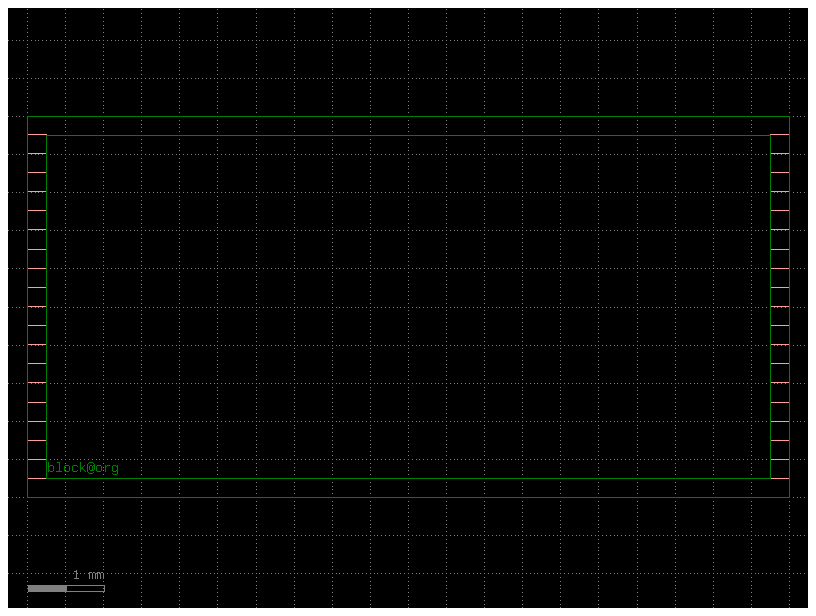

In [139]:
# LO4 - Part b.2
# Arrays of optical I/Os spaced by 250 um

IO_SPACING = 250.0  # um

# Available vertical space, excluding the border
N_IO = int((DIE_WIDTH - 2 * BORDER) / IO_SPACING) + 1

die_io_preview = gf.Component("die_io_preview")

# Die from b.1
die_ref_b2 = die_io_preview << die(
    dieL=DIE_WIDTH,
    dieW=DIE_LENGTH,
    border=BORDER,
    layer_box="FLOORPLAN",
)

# Left-side I/O array
left_io = die_io_preview << gf.components.straight_array(
    n=N_IO,
    spacing=IO_SPACING,
    length=BORDER,
    cross_section="strip",
)
left_io.dmovey(BORDER)

# Right-side I/O array
right_io = die_io_preview << gf.components.straight_array(
    n=N_IO,
    spacing=IO_SPACING,
    length=BORDER,
    cross_section="strip",
)
right_io.dmovex(DIE_LENGTH - BORDER)
right_io.dmovey(BORDER)

print(f"Number of I/Os per side: {N_IO}")

die_io_preview.plot()
die_io_preview.show()

2026-06-12 10:15:53.925 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name   ┃ width ┃ orientation ┃ layer            ┃ center           ┃ port_type ┃
┡━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ W0     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 250.0)   │ optical   │
│ E0     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 250.0)  │ optical   │
│ W1     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 500.0)   │ optical   │
│ E1     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 500.0)  │ optical   │
│ W2     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 750.0)   │ optical   │
│ E2     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 750.0)  │ optical   │
│ W3     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 1000.0)  │ optical   │
│ E3     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 1000.0) │ optical   │
│ W4     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 1250.0)  │ optical   │
│ E4     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 1250.0) │ optical   │
│ W5     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 1500.0)  │ optical   │
│ E5     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 1500.0) │ optical   │
│ W6     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 1750.0)  │ optical   │
│ E6     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 1750.0) │ optical   │
│ W7     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 2000.0)  │ optical   │
│ E7     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 2000.0) │ optical   │
│ W8     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 2250.0)  │ optical   │
│ E8     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 2250.0) │ optical   │
│ W9     │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 2500.0)  │ optical   │
│ E9     │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 2500.0) │ optical   │
│ W10    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 2750.0)  │ optical   │
│ E10    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 2750.0) │ optical   │
│ W11    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 3000.0)  │ optical   │
│ E11    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 3000.0) │ optical   │
│ W12    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 3250.0)  │ optical   │
│ E12    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 3250.0) │ optical   │
│ W13    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 3500.0)  │ optical   │
│ E13    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 3500.0) │ optical   │
│ W14    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 3750.0)  │ optical   │
│ E14    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 3750.0) │ optical   │
│ W15    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 4000.0)  │ optical   │
│ E15    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 4000.0) │ optical   │
│ W16    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 4250.0)  │ optical   │
│ E16    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 4250.0) │ optical   │
│ W17    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 4500.0)  │ optical   │
│ E17    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 4500.0) │ optical   │
│ W18    │ 1.0   │ 0.0         │ WG (1/0)         │ (250.0, 4750.0)  │ optical   │
│ E18    │ 1.0   │ 180.0       │ WG (1/0)         │ (9750.0, 4750.0) │ optical   │
│ origin │ 1.0   │ 0.0         │ FLOORPLAN (99/0) │ (250.0, 250.0)   │ optical   │
└────────┴───────┴─────────────┴──────────────────┴──────────────────┴───────────┘

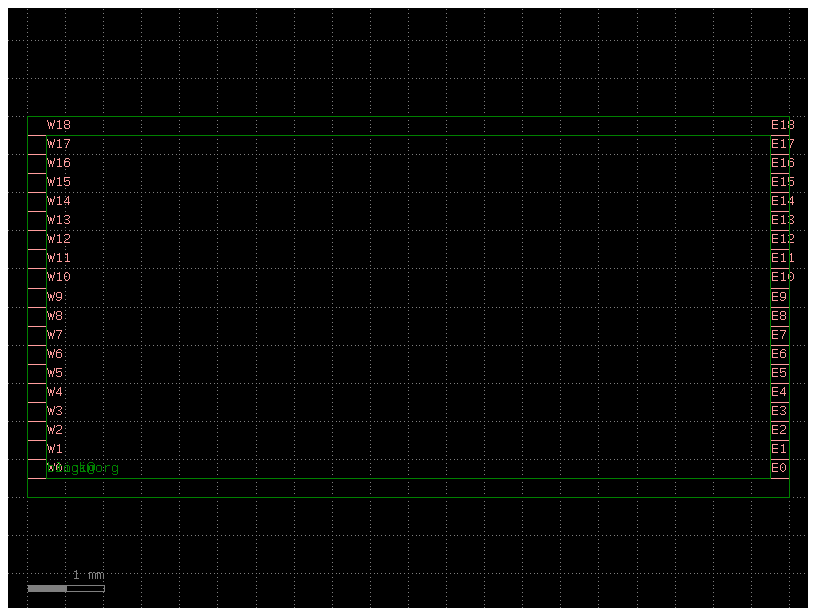

In [140]:
# LO4 - Part b.3
# Reusable 5 mm x 10 mm die cell with accessible optical I/Os

gf.clear_cache()

@gf.cell
def die_5x10_with_ios(
    die_width=5000.0,
    die_length=10000.0,
    border=250.0,
    io_spacing=250.0,
    io_length=250.0,
    cross_section="strip",
):
    c = gf.Component()

    # Die frame from b.1
    frame = c << die(
        dieL=die_width,
        dieW=die_length,
        border=border,
        layer_box="FLOORPLAN",
    )

    # Maximum number of I/Os allowed by the 5 mm width
    n_ios = int((die_width - 2 * border) // io_spacing) + 1

    for i in range(n_ios):
        y = border + i * io_spacing

        # Left I/O
        left = c << gf.components.straight(
            length=io_length,
            cross_section=cross_section,
        )
        left.dmovey(y)

        # Expose its inner port for connection
        c.add_port(name=f"W{i}", port=left["o2"])

        # Right I/O
        right = c << gf.components.straight(
            length=io_length,
            cross_section=cross_section,
        )
        right.dmovex(die_length - io_length)
        right.dmovey(y)

        # Expose its inner port for connection
        c.add_port(name=f"E{i}", port=right["o1"])

    c.add_port(name="origin", port=frame["block@org"])
    c.draw_ports()

    return c


die_b3 = die_5x10_with_ios()

die_b3.plot()
die_b3.show()
die_b3.pprint_ports()

2026-06-12 10:15:54.067 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


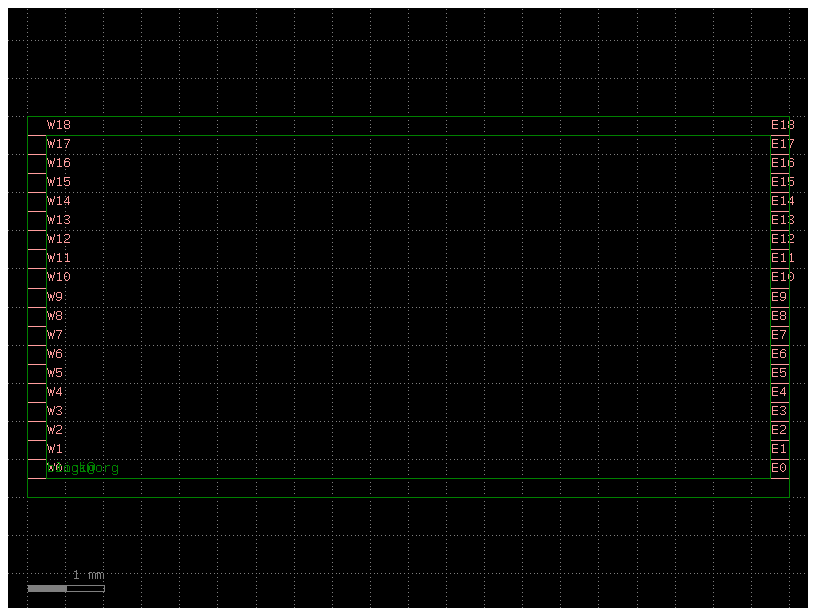

In [141]:
# LO4 - Part c.1
# Create the final layout and instantiate the die as host

gf.clear_cache()

layout_c = gf.Component("lab4_final_layout")

die_host = layout_c << die_5x10_with_ios(
    die_width=5000.0,
    die_length=10000.0,
    border=250.0,
    io_spacing=250.0,
    io_length=250.0,
    cross_section="strip",
)

layout_c.plot()
layout_c.show()

2026-06-12 10:15:54.179 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


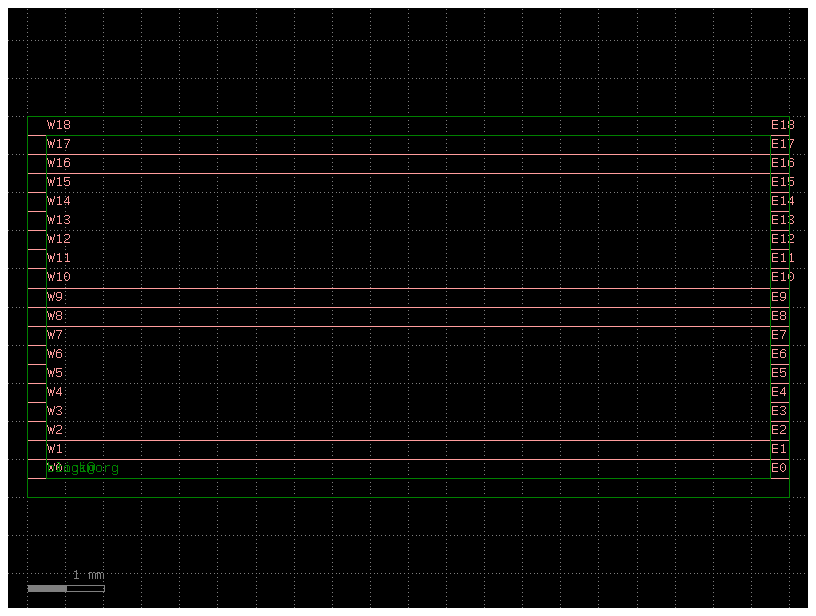

In [142]:
# LO4 - Part c.2
# Three groups of three straight waveguides:
# bottom, middle and top

straight_io_indices = [
    0, 1, 2,       # bottom
    8, 9, 10,      # middle
    16, 17, 18,    # top
]

for i in straight_io_indices:
    gf.routing.route_single(
        component=layout_c,
        port1=die_host[f"W{i}"],
        port2=die_host[f"E{i}"],
        cross_section="strip",
    )

layout_c.plot()
layout_c.show()

2026-06-12 10:15:54.497 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


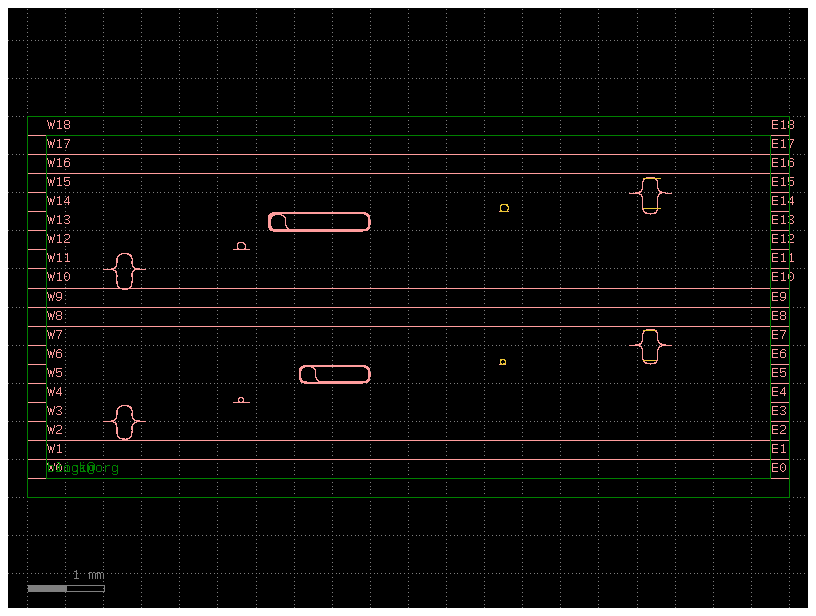

In [143]:
# LO4 - Part c.3
# Add two instances of every component with different lengths

def align_component_to_io(
    reference,
    x_position,
    io_index,
    input_port="o1",
):
    reference.dmovex(
        x_position - reference[input_port].dx
    )

    reference.dmovey(
        die_host[f"W{io_index}"].dy
        - reference[input_port].dy
    )


# LOWER HALF: I/O rows 3 to 7

mzi_1 = layout_c << unbalanced_mzi_lab3(
    delta_L=60.0,
)
align_component_to_io(
    mzi_1,
    x_position=1000.0,
    io_index=3,
)

ring_1 = layout_c << all_pass_ring_lab3(
    extra_length=120.0,
)
align_component_to_io(
    ring_1,
    x_position=2700.0,
    io_index=4,
)

spiral_1 = layout_c << spiral_lab4(
    length=500.0,
)
align_component_to_io(
    spiral_1,
    x_position=4400.0,
    io_index=5,
)

ring_heater_1 = layout_c << all_pass_ring_with_heater_lab3(
    extra_length=120.0,
)
align_component_to_io(
    ring_heater_1,
    x_position=6200.0,
    io_index=6,
)

mzi_heater_1 = layout_c << unbalanced_mzi_with_heaters_lab3(
    delta_L=80.0,
    heater_length=150.0,
)
align_component_to_io(
    mzi_heater_1,
    x_position=7900.0,
    io_index=7,
)


# UPPER HALF: I/O rows 11 to 15

mzi_2 = layout_c << unbalanced_mzi_lab3(
    delta_L=120.125,
)
align_component_to_io(
    mzi_2,
    x_position=1000.0,
    io_index=11,
)

ring_2 = layout_c << all_pass_ring_lab3(
    extra_length=240.0,
)
align_component_to_io(
    ring_2,
    x_position=2700.0,
    io_index=12,
)

spiral_2 = layout_c << spiral_lab4(
    length=900.0,
)
align_component_to_io(
    spiral_2,
    x_position=4400.0,
    io_index=13,
)

ring_heater_2 = layout_c << all_pass_ring_with_heater_lab3(
    extra_length=240.0,
)
align_component_to_io(
    ring_heater_2,
    x_position=6200.0,
    io_index=14,
)

mzi_heater_2 = layout_c << unbalanced_mzi_with_heaters_lab3(
    delta_L=140.0,
    heater_length=220.0,
)
align_component_to_io(
    mzi_heater_2,
    x_position=7900.0,
    io_index=15,
)


layout_c.plot()
layout_c.show()

2026-06-12 10:15:54.666 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


/tmp/ipykernel_1323/1223255488.py:30: UserWarning: No registered width taper for layer 1. Skipping.
  connect_to_io_pair(
/tmp/ipykernel_1323/1223255488.py:37: UserWarning: No registered width taper for layer 1. Skipping.
  connect_to_io_pair(
/tmp/ipykernel_1323/1223255488.py:47: UserWarning: No registered width taper for layer 1. Skipping.
  connect_to_io_pair(
/tmp/ipykernel_1323/1223255488.py:52: UserWarning: No registered width taper for layer 1. Skipping.
  connect_to_io_pair(
/tmp/ipykernel_1323/1223255488.py:61: UserWarning: No registered width taper for layer 1. Skipping.
  connect_to_io_pair(
/tmp/ipykernel_1323/1223255488.py:68: UserWarning: No registered width taper for layer 1. Skipping.
  connect_to_io_pair(
/tmp/ipykernel_1323/1223255488.py:78: UserWarning: No registered width taper for layer 1. Skipping.
  connect_to_io_pair(
/tmp/ipykernel_1323/1223255488.py:83: UserWarning: No registered width taper for layer 1. Skipping.
  connect_to_io_pair(


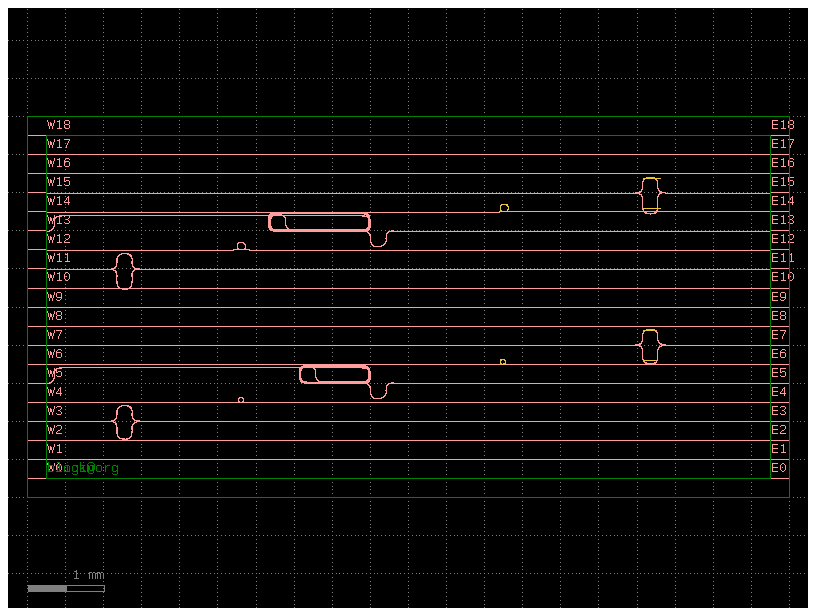

In [144]:
# LO4 - Part c.4
# Connect all components to their corresponding I/O pairs

def connect_to_io_pair(
    reference,
    io_index,
    input_port="o1",
    output_port="o2",
):
    # Left I/O -> component input
    gf.routing.route_single(
        component=layout_c,
        port1=die_host[f"W{io_index}"],
        port2=reference[input_port],
        cross_section="strip",
        allow_width_mismatch=True,
    )

    # Component output -> right I/O
    gf.routing.route_single(
        component=layout_c,
        port1=reference[output_port],
        port2=die_host[f"E{io_index}"],
        cross_section="strip",
        allow_width_mismatch=True,
    )


# Lower half
connect_to_io_pair(
    mzi_1,
    io_index=3,
    input_port="o1",
    output_port="o4",
)

connect_to_io_pair(
    ring_1,
    io_index=4,
)

connect_to_io_pair(
    spiral_1,
    io_index=5,
)

connect_to_io_pair(
    ring_heater_1,
    io_index=6,
)

connect_to_io_pair(
    mzi_heater_1,
    io_index=7,
    input_port="o1",
    output_port="o4",
)


# Upper half
connect_to_io_pair(
    mzi_2,
    io_index=11,
    input_port="o1",
    output_port="o4",
)

connect_to_io_pair(
    ring_2,
    io_index=12,
)

connect_to_io_pair(
    spiral_2,
    io_index=13,
)

connect_to_io_pair(
    ring_heater_2,
    io_index=14,
)

connect_to_io_pair(
    mzi_heater_2,
    io_index=15,
    input_port="o1",
    output_port="o4",
)


layout_c.plot()
layout_c.show()